# MA(q) Parameter Estimation

The moving average model of order $q$, denoted by $\text{MA}(q)$, is defined by,

$
\begin{align}
X_t = \sum_{i=1}^q \vartheta_i \varepsilon_{t-i} + \varepsilon_t
\end{align}
\tag{1}
$

where $\varepsilon_t$ are independent and identically distributed random variables with distribution,

$
\begin{align}
\varepsilon_i \sim \text{Normal}(0, \sigma)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
&\text{E}[\varepsilon_t] = 0 \\
&\text{E}[\varepsilon_t^2] = \sigma^2 \\
&\text{E}[\varepsilon_t \varepsilon_s] = \delta_{ts} \sigma^2
\end{align}
\tag{3}
$

Here the $\vartheta_i$ are estimated given an $MA(q)$ time series. 

## Includes

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def comparison_plot(θ_vals, title, ylim, *params):
    labels = [f"θ={val}" for val in θ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ma_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6))
    return t, scan

## Simulations ($\sigma = 1$)

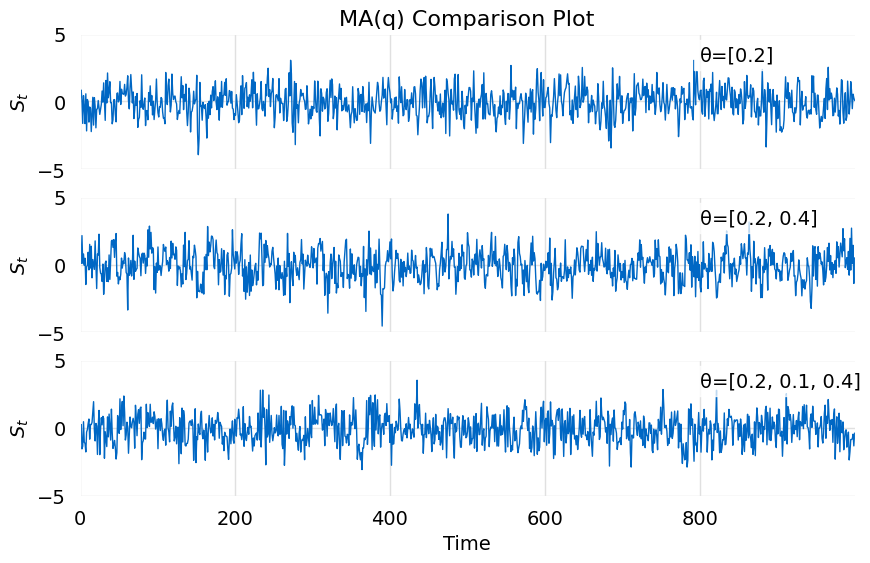

In [3]:
nsample = 1000
σ = 1.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-5.0, 5.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [4]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1447.862
Date:                Sun, 03 Sep 2023   AIC                           2901.723
Time:                        13:17:40   BIC                           2916.447
Sample:                             0   HQIC                          2907.319
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0505      0.040     -1.259      0.208      -0.129       0.028
ma.L1          0.2261      0.031      7.292      0.000       0.165       0.287
sigma2         1.0595      0.045     23.363      0.000       0.971       1.148
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.58
Prob(Q):                              0.98   Prob(JB):                         0.45
Heteroskedasticity (H):               1.00   Skew:                            -0.03
Prob(H) (two-sided):                  0.98   Kurtosis:                         3.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [5]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.05048998318174004,
      "err": 0.04009201005832562,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "581b45f4-48ef-4891-a108-c38af1ac6d21",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.22609323887750107,
         "err": 0.031006283237049837,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "581b45f4-48ef-4891-a108-c38af1ac6d21",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 1.0594876619461961,
      "err": 0.045349518341532495,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [6]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1425.485
Date:                Sun, 03 Sep 2023   AIC                           2858.969
Time:                        13:17:40   BIC                           2878.600
Sample:                             0   HQIC                          2866.430
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0830      0.053     -1.556      0.120      -0.188       0.022
ma.L1          0.2444      0.030      8.059      0.000       0.185       0.304
ma.L2          0.4289      0.027     16.047      0.000       0.377       0.481
sigma2         1.0127      0.045     22.568      0.000       0.925       1.101
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.30
Prob(Q):                              0.92   Prob(JB):                         0.86
Heteroskedasticity (H):               0.81   Skew:                            -0.04
Prob(H) (two-sided):                  0.06   Kurtosis:                         3.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.08301760659288628,
      "err": 0.05334852237427575,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "c86ce70c-8b11-43db-81fa-783b55d6f839",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.2443527565600249,
         "err": 0.03032095655749985,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c86ce70c-8b11-43db-81fa-783b55d6f839",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.4289433165254934,
         "err": 0.026730972589037304,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
      

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [8]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -1401.363
Date:                Sun, 03 Sep 2023   AIC                           2812.725
Time:                        13:17:40   BIC                           2837.264
Sample:                             0   HQIC                          2822.052
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1072      0.049     -2.174      0.030      -0.204      -0.011
ma.L1          0.1667      0.031      5.421      0.000       0.106       0.227
ma.L2          0.0653      0.031      2.126      0.033       0.005       0.125
ma.L3          0.3502      0.029     11.939      0.000       0.293       0.408
sigma2         0.9650      0.046     20.985      0.000       0.875       1.055
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 3.50
Prob(Q):                              0.72   Prob(JB):                         0.17
Heteroskedasticity (H):               1.04   Skew:                            -0.09
Prob(H) (two-sided):                  0.74   Kurtosis:                         2.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.10721091739737704,
      "err": 0.04931087409789165,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "98514aa1-84de-4b40-b713-4e088a5875f1",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.16671060919020847,
         "err": 0.03075093317581226,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "98514aa1-84de-4b40-b713-4e088a5875f1",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.06528241999622315,
         "err": 0.030702627359518054,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
    

## Simulations ($\sigma = 5$)

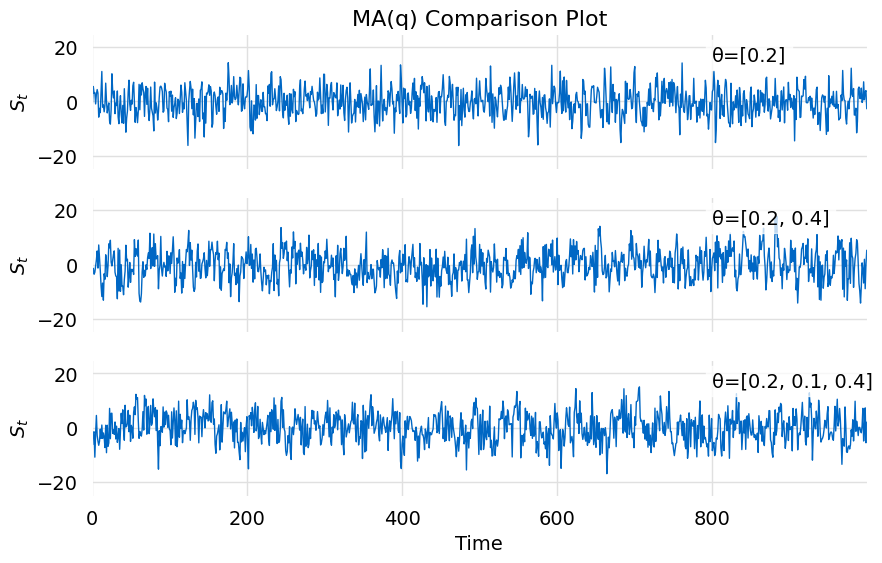

In [10]:
nsample = 1000
σ = 5.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-25.0, 25.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [11]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -3034.891
Date:                Sun, 03 Sep 2023   AIC                           6075.783
Time:                        13:17:40   BIC                           6090.506
Sample:                             0   HQIC                          6081.379
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2017      0.193     -1.044      0.296      -0.580       0.177
ma.L1          0.2129      0.031      6.810      0.000       0.152       0.274
sigma2        25.3263      1.131     22.389      0.000      23.109      27.543
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.55
Prob(Q):                              0.95   Prob(JB):                         0.76
Heteroskedasticity (H):               1.07   Skew:                            -0.06
Prob(H) (two-sided):                  0.55   Kurtosis:                         3.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.2017435239484737,
      "err": 0.19324629233741705,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "9c82867f-9df4-4379-8821-cfdff7f87824",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.21286425051722332,
         "err": 0.031255326459478774,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "9c82867f-9df4-4379-8821-cfdff7f87824",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 25.32629239599683,
      "err": 1.1312173318421677,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "9c82

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [13]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -3011.093
Date:                Sun, 03 Sep 2023   AIC                           6030.187
Time:                        13:17:40   BIC                           6049.818
Sample:                             0   HQIC                          6037.648
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2221      0.257     -0.865      0.387      -0.725       0.281
ma.L1          0.2035      0.028      7.200      0.000       0.148       0.259
ma.L2          0.4474      0.029     15.401      0.000       0.390       0.504
sigma2        24.1393      1.135     21.273      0.000      21.915      26.363
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.39
Prob(Q):                              0.95   Prob(JB):                         0.30
Heteroskedasticity (H):               1.06   Skew:                            -0.08
Prob(H) (two-sided):                  0.62   Kurtosis:                         2.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.22214013332755272,
      "err": 0.25677762144105926,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "32f38510-d1bf-458f-aa86-6a07e1a1b2c1",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.20345782099061666,
         "err": 0.028256742817926797,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "32f38510-d1bf-458f-aa86-6a07e1a1b2c1",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.4473603829199013,
         "err": 0.029048334137776594,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
    

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [15]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -3002.858
Date:                Sun, 03 Sep 2023   AIC                           6015.715
Time:                        13:17:40   BIC                           6040.254
Sample:                             0   HQIC                          6025.042
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0093      0.273      0.034      0.973      -0.525       0.544
ma.L1          0.2197      0.029      7.683      0.000       0.164       0.276
ma.L2          0.1307      0.030      4.320      0.000       0.071       0.190
ma.L3          0.4095      0.030     13.532      0.000       0.350       0.469
sigma2        23.7419      1.107     21.457      0.000      21.573      25.911
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 2.71
Prob(Q):                              0.89   Prob(JB):                         0.26
Heteroskedasticity (H):               0.99   Skew:                            -0.11
Prob(H) (two-sided):                  0.92   Kurtosis:                         2.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": 0.009346698979179903,
      "err": 0.2726488334758084,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "47232bca-4b89-4839-b4b4-7a925c251ae1",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.2197026483715537,
         "err": 0.028594230148828004,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "47232bca-4b89-4839-b4b4-7a925c251ae1",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.13067042852661084,
         "err": 0.030244814172550306,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
     